### `Explanatory Data Analysis on Household Power Consumption`

`Loading Libraries`

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns; sns.set_theme()
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

`Importing Dataset`

In [4]:
consumption = pd.read_csv('../dataset/power_consumption.txt', sep=';', na_values='?', low_memory=False)

consumption.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


`Parsing Datetime and Set Index`

In [5]:
# Combining Date and time
consumption['Datetime'] = pd.to_datetime(consumption['Date'] + ' ' + consumption['Time'], dayfirst=True)
consumption.drop(columns=['Date', 'Time'], inplace=True)
consumption.set_index('Datetime', inplace=True)

# Converting all columns to numeric
consumption = consumption.apply(pd.to_numeric, errors='coerce')

In [6]:
consumption.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


`Explanatory Data Analysis`

In [7]:
print(f'\n ==== Shape of the dataset ==== \n {consumption.shape} \n')

print(f'\n ==== Information about the dataset ==== \n')
print(f'{consumption.info()}')


 ==== Shape of the dataset ==== 
 (2075259, 7) 


 ==== Information about the dataset ==== 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
None


`Handling Missing Values`

In [8]:
consumption.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

`Forward fill` - safe for time series data, uses last known readings

In [9]:
consumption.ffill(inplace=True)
print(f'\n After Fill: {consumption.isnull().sum().sum()}')


 After Fill: 0


`Resampling to Hourly and Daily`

In [10]:
# Hourly aggregation (mean for power, sum of energy)
consumption_hourly = consumption.resample('h').mean()

# Daily aggregation
consumption_daily = consumption.resample('d').mean()

print('Hourly Shape: ', consumption_hourly.shape)
print('Daily Shape: ', consumption_daily.shape)

Hourly Shape:  (34589, 7)
Daily Shape:  (1442, 7)


In [11]:
consumption_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [12]:
consumption_daily.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


`Feature Engineering`

In [13]:
consumption_hourly['hour'] = consumption_hourly.index.hour
consumption_hourly['day_of_week'] = consumption_hourly.index.dayofweek
consumption_hourly['month'] = consumption_hourly.index.month
consumption_hourly['year'] = consumption_hourly.index.year
consumption_hourly['is_weekend'] = consumption_hourly['day_of_week'].isin([5, 6]).astype(int)

consumption_hourly['season'] = consumption_hourly['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Lag Features
consumption_hourly['lag_1h'] = consumption_hourly['Global_active_power'].shift(1)
consumption_hourly['lag_24h'] = consumption_hourly['Global_active_power'].shift(24)

# Rolling averages
consumption_hourly['rolling_mean_6h'] = consumption_hourly['Global_active_power'].rolling(6).mean()
consumption_hourly['rolling_mean_24h'] = consumption_hourly['Global_active_power'].rolling(24).mean()

consumption_hourly.dropna(inplace=True)
print(f'==== Shape of Consumption hourly ==== \n {consumption_hourly.shape}')
consumption_hourly.head()

==== Shape of Consumption hourly ==== 
 (34565, 17)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,year,is_weekend,season,lag_1h,lag_24h,rolling_mean_6h,rolling_mean_24h
Datetime,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,12,2006,1,Winter,3.326033,4.222889,2.564578,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,12,2006,1,Winter,3.406767,3.632200,2.861450,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,12,2006,1,Winter,3.697100,3.400233,3.069389,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,12,2006,1,Winter,2.908400,3.268567,3.280867,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,12,2006,1,Winter,3.361500,3.056467,3.290094,2.450569


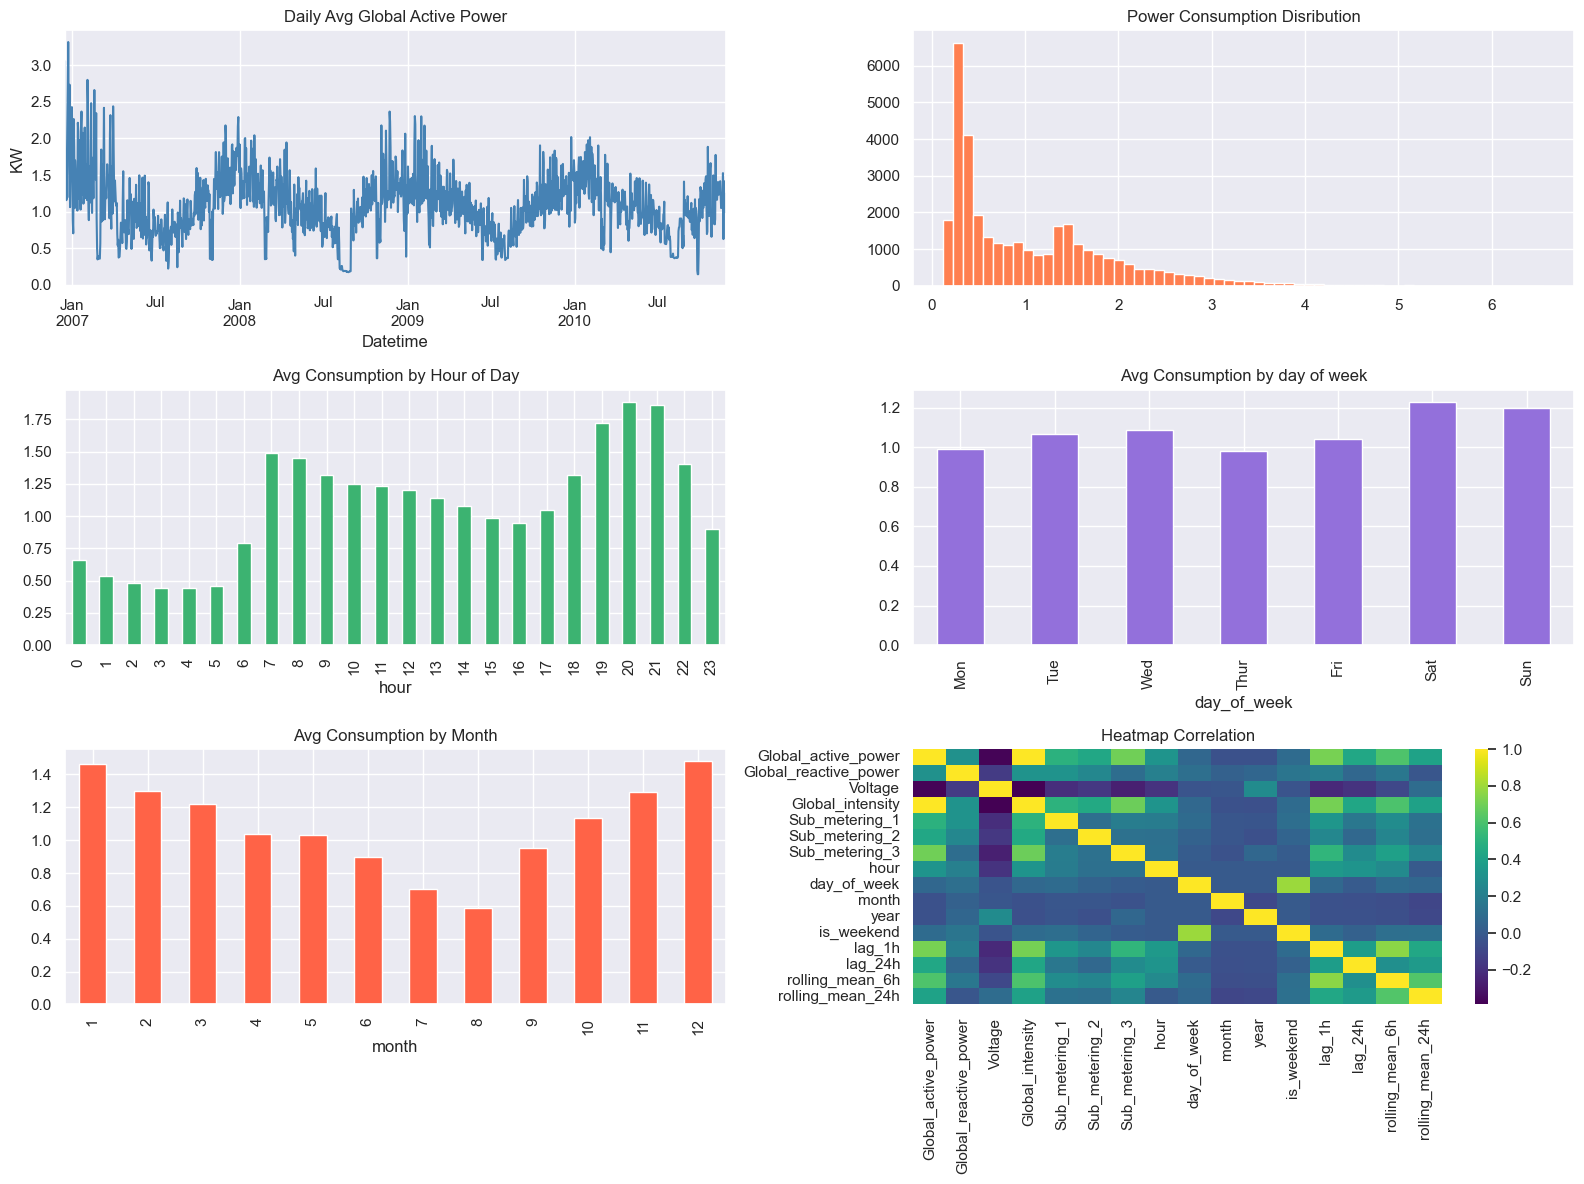

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Daily average power usage
consumption_daily['Global_active_power'].plot(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Daily Avg Global Active Power')
axes[0, 0].set_ylabel('KW')

# Distribution
consumption_hourly['Global_active_power'].hist(ax=axes[0, 1], bins=60, color='coral')
axes[0, 1].set_title('Power Consumption Disribution')

# Average by hour of day
consumption_hourly.groupby('hour')['Global_active_power'].mean().plot(
    kind='bar', ax=axes[1, 0], color='mediumseagreen'
)
axes[1, 0].set_title('Avg Consumption by Hour of Day')

# Average by dey of week
consumption_hourly.groupby('day_of_week')['Global_active_power'].mean().plot(
    kind='bar', ax=axes[1, 1], color='mediumpurple'
)
axes[1, 1].set_title('Avg Consumption by day of week')
axes[1, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun'])

# Average by month
consumption_hourly.groupby('month')['Global_active_power'].mean().plot(
    kind='bar', ax=axes[2, 0], color='tomato'
)
axes[2, 0].set_title('Avg Consumption by Month')

# Correlation Heatmap
numeric_cols = consumption_hourly.select_dtypes(include=['number']).corr()
sns.heatmap(numeric_cols, ax=axes[2, 1], annot=False, cmap='viridis')
plt.title('Heatmap Correlation')

plt.tight_layout()
plt.savefig('../plots/eda_phase.png', dpi=150)
plt.show()